In [2]:
#!pip install snowflake-connector-python

In [1]:
import snowflake.connector
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv('../.env')

conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    schema='CLEAN'
)

ibm_maven = pd.read_sql('SELECT * FROM IBM_MAVEN', conn)
kaggle = pd.read_sql('SELECT * FROM KAGGLE_TELECOMS', conn)

print(f'IBM+Maven: {ibm_maven.shape}')
print(f'Kaggle: {kaggle.shape}')

/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_6018/760262173.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ibm_maven = pd.read_sql('SELECT * FROM IBM_MAVEN', conn)
/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_6018/760262173.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  kaggle = pd.read_sql('SELECT * FROM KAGGLE_TELECOMS', conn)


IBM+Maven: (6589, 34)
Kaggle: (3333, 22)


In [2]:
print(ibm_maven.columns.tolist())
print()
print(ibm_maven['CHURN'].value_counts())

['CUSTOMERID', 'GENDER', 'AGE', 'MARRIED', 'DEPENDENTS', 'CITY', 'ZIP_CODE', 'SENIORCITIZEN', 'TENURE', 'PHONESERVICE', 'MULTIPLELINES', 'INTERNETSERVICE', 'INTERNET_TYPE', 'ONLINESECURITY', 'ONLINEBACKUP', 'DEVICEPROTECTION', 'TECHSUPPORT', 'STREAMINGTV', 'STREAMINGMOVIES', 'STREAMING_MUSIC', 'UNLIMITED_DATA', 'CONTRACT', 'PAPERLESSBILLING', 'PAYMENTMETHOD', 'MONTHLYCHARGES', 'TOTALCHARGES', 'TOTAL_REVENUE', 'TOTAL_REFUNDS', 'NUMBER_OF_REFERRALS', 'OFFER', 'AVG_MONTHLY_GB_DOWNLOAD', 'CHURN', 'CHURN_CATEGORY', 'CHURN_REASON']

CHURN
No     4720
Yes    1869
Name: count, dtype: int64


In [3]:
#data aoverview
print("IBM + Maven")
print(f"Shape: {ibm_maven.shape}")
print(f"\nChurn distribution:")
print(ibm_maven['CHURN'].value_counts())
print(f"\nChurn rate: {(ibm_maven['CHURN']=='Yes').mean()*100:.1f}%")

print("\n\nKaggle Telecoms")
print(f"Shape: {kaggle.shape}")
print(f"\nChurn distribution:")
print(kaggle['CHURN_FLAG'].value_counts())
print(f"\nChurn rate: {(kaggle['CHURN_FLAG']=='Yes').mean()*100:.1f}%")

IBM + Maven
Shape: (6589, 34)

Churn distribution:
CHURN
No     4720
Yes    1869
Name: count, dtype: int64

Churn rate: 28.4%


Kaggle Telecoms
Shape: (3333, 22)

Churn distribution:
CHURN_FLAG
No     2850
Yes     483
Name: count, dtype: int64

Churn rate: 14.5%


In [5]:
#nullss
print("IBM+Maven nulls")
nulls = ibm_maven.isnull().sum()
print(nulls[nulls > 0])

print("\nKaggle nulls")
nulls_k = kaggle.isnull().sum()
print(nulls_k[nulls_k > 0])

IBM+Maven nulls
INTERNET_TYPE              1344
STREAMING_MUSIC            1344
UNLIMITED_DATA             1344
TOTALCHARGES                 11
OFFER                      3598
AVG_MONTHLY_GB_DOWNLOAD    1344
CHURN_CATEGORY             4720
CHURN_REASON               4720
dtype: int64

Kaggle nulls
Series([], dtype: int64)


## ANALYSIS


In [7]:
import os
os.makedirs('figures', exist_ok=True)

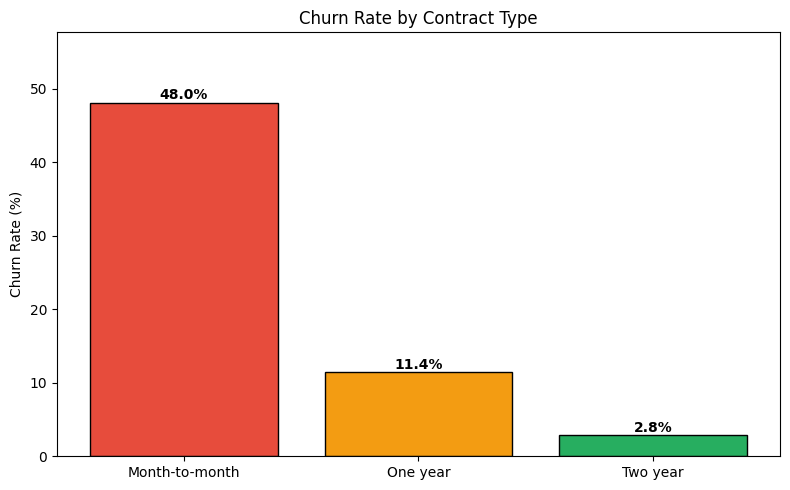

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# churn rate by contract type
contract_churn = ibm_maven.groupby('CONTRACT')['CHURN'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']
contract_churn = contract_churn.sort_values('Churn Rate (%)', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
              color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='black')
for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type')
ax.set_ylim(0, max(contract_churn['Churn Rate (%)']) * 1.2)
plt.tight_layout()
plt.savefig('figures/01_churn_by_contract.png', dpi=150)
plt.show()

/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_6018/3385389290.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = ibm_maven.groupby('TENURE_COHORT')['CHURN'].apply(


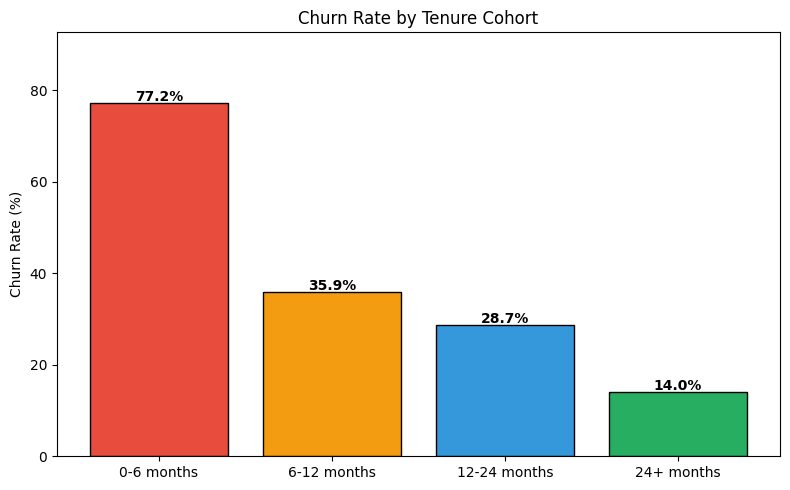

In [12]:
#CHURN BY TENURE

# create tenure cohorts
ibm_maven['TENURE_COHORT'] = pd.cut(ibm_maven['TENURE'], 
    bins=[0, 6, 12, 24, 100],
    labels=['0-6 months', '6-12 months', '12-24 months', '24+ months'])

tenure_churn = ibm_maven.groupby('TENURE_COHORT')['CHURN'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
tenure_churn.columns = ['Cohort', 'Churn Rate (%)']

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
bars = ax.bar(tenure_churn['Cohort'], tenure_churn['Churn Rate (%)'],
              color=colors, edgecolor='black')
for bar, val in zip(bars, tenure_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Tenure Cohort')
ax.set_ylim(0, max(tenure_churn['Churn Rate (%)']) * 1.2)
plt.tight_layout()
plt.savefig('figures/02_churn_by_tenure.png', dpi=150)
plt.show()

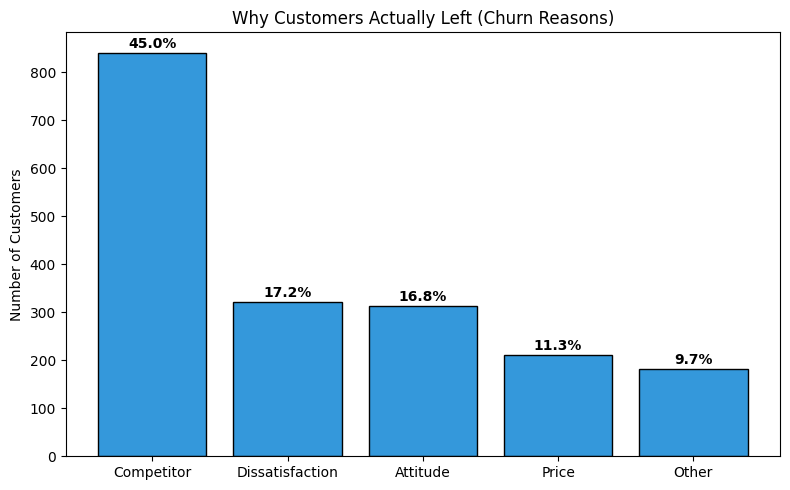

In [13]:
#chart-  reasons why customers actually left
reasons = ibm_maven[ibm_maven['CHURN'] == 'Yes']['CHURN_CATEGORY'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(reasons.index, reasons.values, color='#3498db', edgecolor='black')
for bar, val in zip(bars, reasons.values):
    pct = val / reasons.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{pct:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_title('Why Customers Actually Left (Churn Reasons)')
plt.tight_layout()
plt.savefig('figures/03_churn_reasons.png', dpi=150)
plt.show()

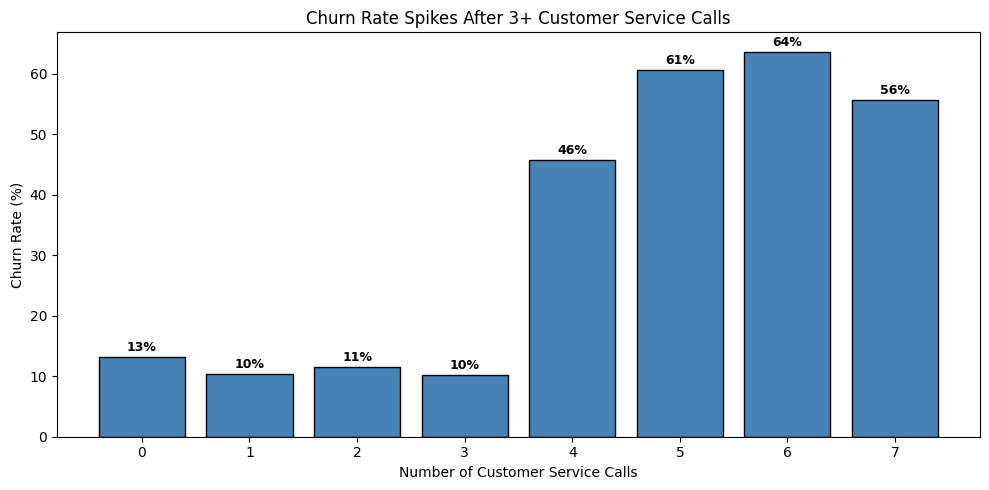

In [14]:
#chart4-  customer service calls vs churn (from kaggle dataset)
cs_churn = kaggle.groupby('CUSTOMER_SERVICE_CALLS')['CHURN_FLAG'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
cs_churn.columns = ['Calls', 'Churn Rate (%)']
cs_churn = cs_churn[cs_churn['Calls'] <= 7]  # cap for readability

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cs_churn['Calls'], cs_churn['Churn Rate (%)'], 
              color='steelblue', edgecolor='black')
for bar, val in zip(bars, cs_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontweight='bold', fontsize=9)
ax.set_xlabel('Number of Customer Service Calls')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate Spikes After 3+ Customer Service Calls')
plt.tight_layout()
plt.savefig('figures/04_churn_by_service_calls.png', dpi=150)
plt.show()

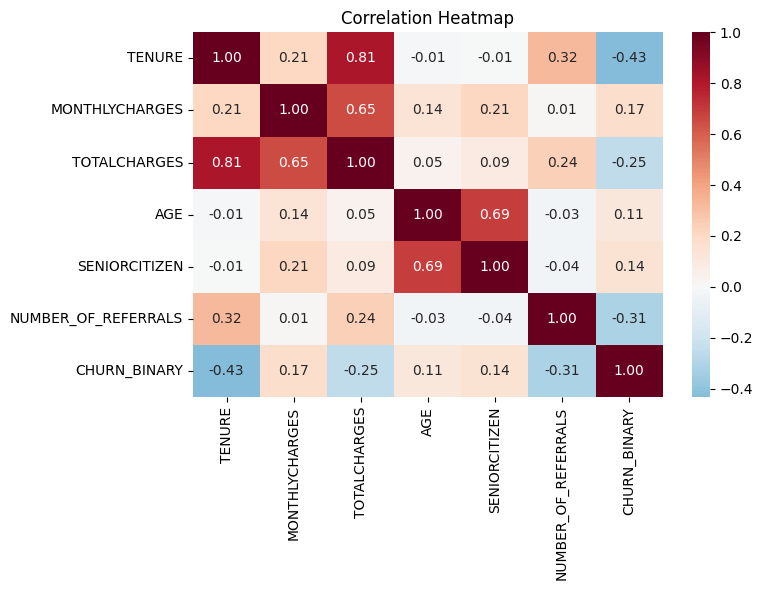

In [15]:
# correlation heatmap for IBM+Maven
ibm_maven['CHURN_BINARY'] = (ibm_maven['CHURN'] == 'Yes').astype(int)

numeric_cols = ['TENURE', 'MONTHLYCHARGES', 'TOTALCHARGES', 'AGE', 
                'SENIORCITIZEN', 'NUMBER_OF_REFERRALS', 'CHURN_BINARY']
corr = ibm_maven[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('figures/05_correlation_heatmap.png', dpi=150)
plt.show()

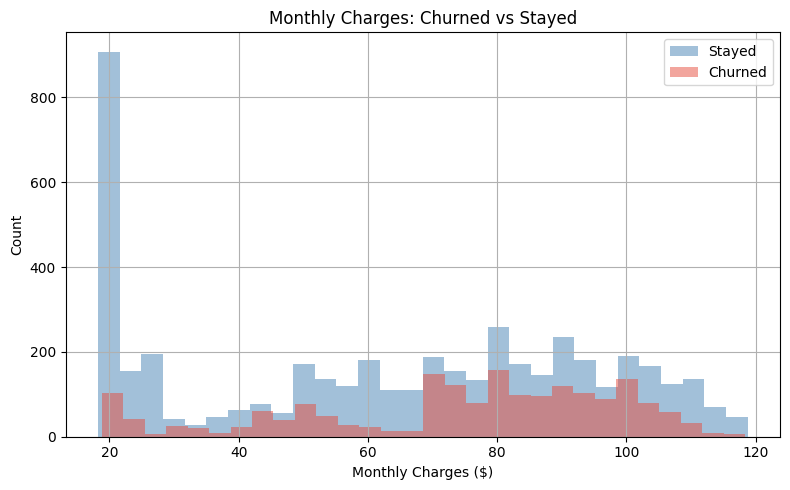

In [16]:
#Chart 6 — Monthly charges distribution
#churned vs stayed
fig, ax = plt.subplots(figsize=(8, 5))
ibm_maven[ibm_maven['CHURN']=='No']['MONTHLYCHARGES'].hist(
    bins=30, alpha=0.5, label='Stayed', color='steelblue', ax=ax)
ibm_maven[ibm_maven['CHURN']=='Yes']['MONTHLYCHARGES'].hist(
    bins=30, alpha=0.5, label='Churned', color='#e74c3c', ax=ax)
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Count')
ax.set_title('Monthly Charges: Churned vs Stayed')
ax.legend()
plt.tight_layout()
plt.savefig('figures/06_monthly_charges_dist.png', dpi=150)
plt.show()